In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error


In [2]:
!pip install yfinance
import yfinance as yf

# Download Google (GOOG) stock prices
data = yf.download("GOOG", start="2010-01-01", end="2024-12-31")
data = data[['Close']]
data.head()


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,GOOG
Date,
2010-01-04,15.536651
2010-01-05,15.468232
2010-01-06,15.078299
2010-01-07,14.727281
2010-01-08,14.923613


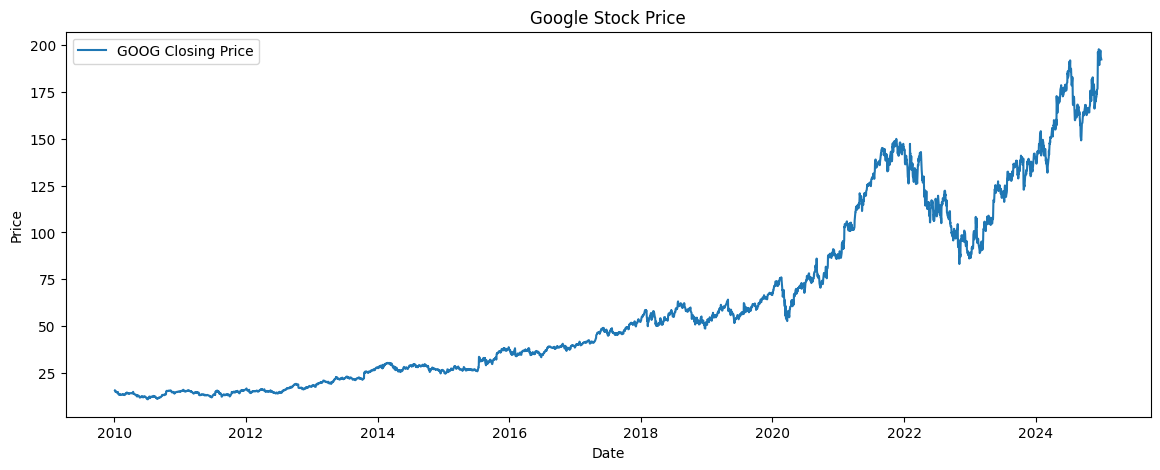

In [3]:
plt.figure(figsize=(14,5))
plt.plot(data['Close'], label='GOOG Closing Price')
plt.title('Google Stock Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


In [4]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

sequence_length = 60
X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))  # [samples, timesteps, features]

# Train-test split
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [5]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50))
model.add(Dropout(0.2))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 13s 69ms/step - loss: 0.0101 - val_loss: 0.0020
Epoch 2/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - loss: 7.3040e-04 - val_loss: 0.0018
Epoch 3/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 12s 91ms/step - loss: 7.7863e-04 - val_loss: 0.0041
Epoch 4/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - loss: 7.4092e-04 - val_loss: 0.0011
Epoch 5/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - loss: 4.9877e-04 - val_loss: 9.5639e-04
Epoch 6/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - loss: 5.6222e-04 - val_loss: 0.0012
Epoch 7/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 5.1165e-04 - val_loss: 8.7017e-04
Epoch 8/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - loss: 4.3017e-04 - val_loss: 0.0012
Epoch 9/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - loss: 3.9599e-04 - val_loss: 0.0018
Epoch 10/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - loss: 4.4546e-04 - val_loss: 9.4652e-04
Epoch 11/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - loss: 4.1333e-04 - val_loss: 0.0012
Epoc

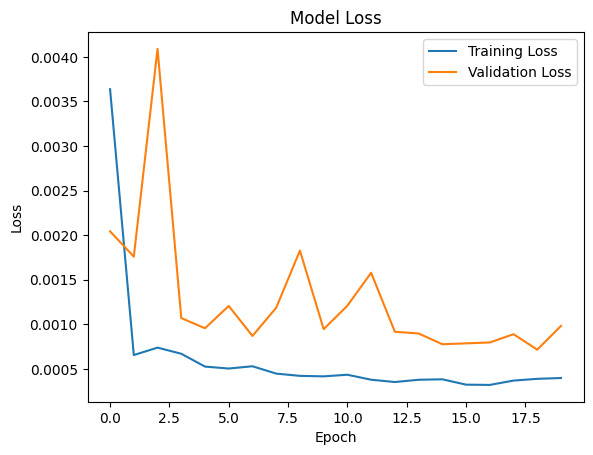

In [7]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


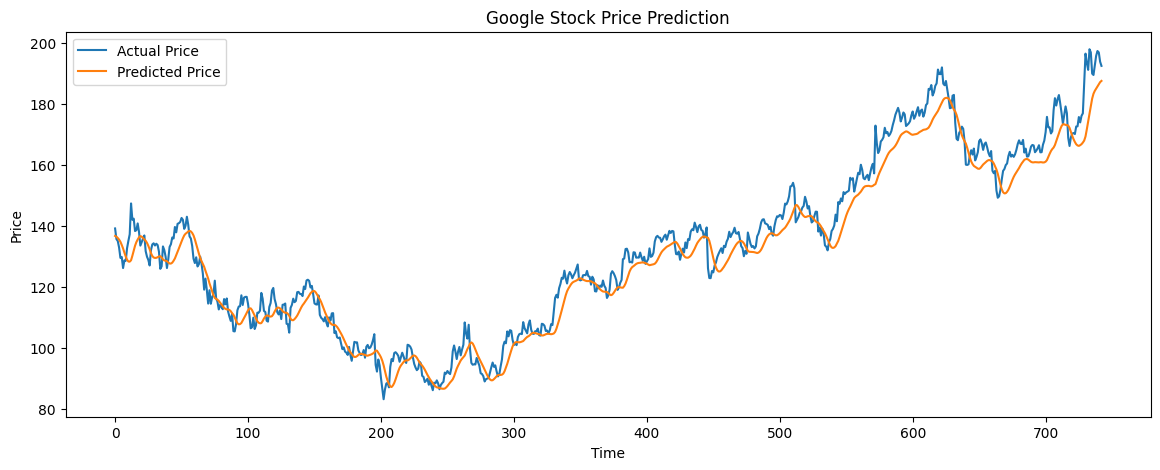

In [8]:
predicted_prices = model.predict(X_test)
predicted_prices = scaler.inverse_transform(predicted_prices.reshape(-1, 1))
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

plt.figure(figsize=(14,5))
plt.plot(actual_prices, label="Actual Price")
plt.plot(predicted_prices, label="Predicted Price")
plt.title("Google Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()


In [9]:
mse = mean_squared_error(actual_prices, predicted_prices)
print(f"Mean Squared Error: {mse:.4f}")


Mean Squared Error: 34.4198
